# Gaussian Processes Summer School

## Part 3: Implicit Neural Spectral Kernels

<a href="https://www.uc3m.es/"><img src="./uc3m.png" alt="Universidad Carlos III de Madrid" width="520"></a>

**Author:** [Pablo M. Olmos](https://olmos-pm.github.io/)

**Email:** [pamartin@ing.uc3m.es](mailto:pamartin@ing.uc3m.es)

---

Here we learn a flexible spectral kernel through **implicit neural sampler**: a dense network maps Gaussian noise directly to spectral frequencies. We never evaluate a spectral density. Instead, differentiable samples define random Fourier features (RFFs), and the sampler is learned through GP marginal likelihood with an $L_2$ penalty against unnecessarily high frequencies.

## 1. Imports

The helper is explicitly reloaded so edits to the local Python file are picked up even when this notebook is run in an existing VS Code kernel.

In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from generate_gp_mixture import generate_gp_mixture
import train_implicit_spectral_gp as implicit_helpers
importlib.reload(implicit_helpers)
from train_implicit_spectral_gp import (
    as_tensors,
    build_implicit_spectral_gp,
    predict_sparse_signal,
    train_implicit_spectral_gp,
)

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)
torch.manual_seed(7)


## 2. The same three-component GP mixture

As in Parts 2, each curve first receives a categorical component,

$$z_i^{\rm cat}\sim\operatorname{Categorical}(\pi_1,\pi_2,\pi_3),$$

and is then sampled from

$$f_i\mid z_i^{\rm cat}=m\sim\mathcal{GP}(0,k_m),\qquad k_m(\tau)=\exp\!\left(-\frac{\tau^2}{2\ell_m^2}\right)\cos(\omega_m\tau),$$

where $\omega_m=2\pi/T_m$. Independent Gaussian jittering noise is added to each sampled curve. The normalized component spectrum is

$$p_m(\omega)=\tfrac12\mathcal N(\omega;\omega_m,\ell_m^{-2})+\tfrac12\mathcal N(\omega;-\omega_m,\ell_m^{-2}),$$

so a single shared model should learn the aggregate spectrum $p_{\rm true}=\sum_m\pi_mp_m$ and aggregate kernel $k_{\rm avg}=\sum_m\pi_mk_m$.

In [2]:
seed = 7
n_curves = 300
x = np.linspace(0.0, 2.0, 200)
periods = np.array([1.0, 0.5, 0.25])
angular_frequencies = 2 * np.pi / periods
lengthscales = np.array([0.6, 0.6, 0.6])
mixture_weights = np.array([1/3, 1/3, 1/3])
noise_std = 0.05

curves, labels = generate_gp_mixture(
    x=x, n_curves=n_curves, periods=periods,
    lengthscales=lengthscales, mixture_weights=mixture_weights,
    noise_std=noise_std, seed=seed,
)

# Split the dataset into training and testing sets
split_rng = np.random.default_rng(seed + 2)
permutation = split_rng.permutation(n_curves)
n_train = int(0.8 * n_curves)
train_idx, test_idx = permutation[:n_train], permutation[n_train:]
train_curves, test_curves = curves[train_idx], curves[test_idx]
train_labels, test_labels = labels[train_idx], labels[test_idx]

pd.DataFrame({
    'component': np.arange(1, 4),
    'period $T_m$': periods,
    'frequency $\\omega_m$': angular_frequencies,
    'lengthscale $\\ell_m$': lengthscales,
    'population weight': mixture_weights,
    'training share': np.bincount(train_labels, minlength=3) / n_train,
})


,component,period $T_m$,frequency $\omega_m$,lengthscale $\ell_m$,population weight,training share
0,1,1.00,6.283185,0.6,0.333333,0.3125
1,2,0.50,12.566371,0.6,0.333333,0.3500
2,3,0.25,25.132741,0.6,0.333333,0.3375


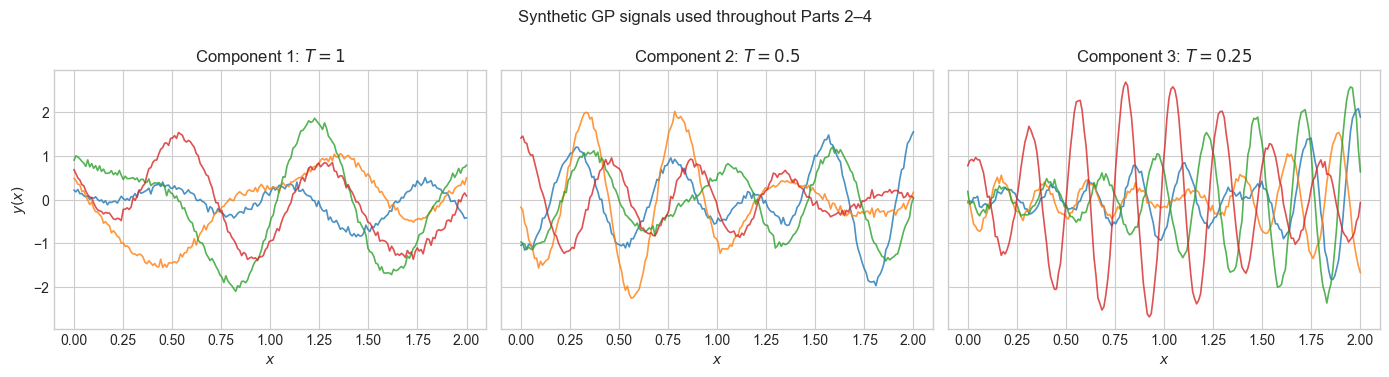

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True, sharey=True)
for component, ax in enumerate(axes):
    for curve_index in np.flatnonzero(labels == component)[:4]:
        ax.plot(x, curves[curve_index], lw=1.2, alpha=0.8)
    ax.set_title(f'Component {component + 1}: $T={periods[component]:g}$')
    ax.set_xlabel('$x$')
axes[0].set_ylabel('$y(x)$')
fig.suptitle('Synthetic GP signals used throughout Parts 2–4')
fig.tight_layout()
plt.show()


## 3. An implicit neural spectral sampler

Let $D$ be the dimension of the GP input $x\in\mathbb R^D$, and choose a noise dimension $K$. For each of the $L$ RFF frequencies, draw

$$\mathbf z_l\sim\mathcal N(\mathbf 0,I_K),\qquad \mathbf z_l\in\mathbb R^K,$$

then transform it with a dense neural network

$$\widetilde{\boldsymbol\omega}_l=a_\theta g_\theta(\mathbf z_l),\qquad g_\theta:\mathbb R^K\rightarrow\mathbb R^D,$$

where $a_\theta>0$ is a learned global frequency scale. In this example, $K=8$ and **$D=1$**, because the signals are functions of one scalar input.

The network has three hidden layers with SiLU activations:

$$\mathbf z_l\xrightarrow{\text{Dense+SiLU}}\mathbf h_1\xrightarrow{\text{Dense+SiLU}}\mathbf h_2\xrightarrow{\text{Dense+SiLU}}\mathbf h_3\xrightarrow{\text{Dense}}\widetilde{\boldsymbol\omega}_l.$$

This construction defines a distribution through sampling, but generally does not provide a tractable formula for its density.

<div style="display:block; box-sizing:border-box; width:100%; max-width:100%; overflow-x:auto; white-space:normal; background:#e8f3ff; border-left:6px solid #1976d2; padding:14px 18px; margin:16px 0;">
<strong>Normalizing flow versus implicit sampler</strong><br>
A normalizing flow is invertible and tracks a Jacobian determinant, so its density can be evaluated. This dense generator need not be invertible: typically $K\neq D$, and many noise vectors may map to similar frequencies. That greater freedom is useful because GP training below needs samples from the spectrum, not the numerical value of its density.
</div>

| Property | RealNVP spectrum | Implicit MLP spectrum |
|---|---:|---:|
| Sample frequencies | Yes | Yes |
| Differentiable pathwise samples | Yes | Yes |
| Invertible map | Yes | No requirement |
| Tractable density | Yes | Generally no |
| Noise and output dimensions | Usually equal | May differ ($K\neq D$) |

## 4. Symmetrization and random Fourier features

Draw an independent Rademacher variable $b_l\in\{-1,+1\}$ and define

$$\boldsymbol\omega_l=b_l\widetilde{\boldsymbol\omega}_l.$$

For a raw implicit law $q_\theta$, this sampling procedure produces the symmetric measure

$$p_\theta(\boldsymbol\omega)=\tfrac12q_\theta(\boldsymbol\omega)+\tfrac12q_\theta(-\boldsymbol\omega).$$

The paired RFF representation is

$$\phi_\theta(\mathbf x)=\frac1{\sqrt L}\left[\cos(\boldsymbol\omega_1^\top\mathbf x),\ldots,\cos(\boldsymbol\omega_L^\top\mathbf x),\sin(\boldsymbol\omega_1^\top\mathbf x),\ldots,\sin(\boldsymbol\omega_L^\top\mathbf x)\right],$$

$$k_\theta(\mathbf x,\mathbf x')\approx\phi_\theta(\mathbf x)^\top\phi_\theta(\mathbf x')=\frac1L\sum_{l=1}^L\cos\!\left(\boldsymbol\omega_l^\top(\mathbf x-\mathbf x')\right).$$

For paired sine/cosine features, a sign flip leaves the kernel contribution unchanged because cosine is even. It nevertheless makes the sampled spectral measure explicitly symmetric.

## 5. Stochastic evidence training with a frequency penalty

At every optimization step $t$, we independently redraw $\{\mathbf z_l^{(t)},b_l^{(t)}\}_{l=1}^L$. Conditional on these draws, $\boldsymbol\omega_l^{(t)}$ is differentiable with respect to the MLP weights and frequency scale. We minimize

$$\mathcal J_t(\theta)=-\frac1B\sum_{i=1}^B\log p(\mathbf y_i\mid X,\theta,\{\mathbf z_l^{(t)},b_l^{(t)}\})+\lambda_\omega\frac1L\sum_{l=1}^L\|\boldsymbol\omega_l^{(t)}\|_2^2.$$

Thus the GP evidence supplies the learning signal without requiring $\log p_\theta(\omega)$.

<div style="display:block; box-sizing:border-box; width:100%; max-width:100%; overflow-x:auto; white-space:normal; background:#fff4e5; border-left:6px solid #ef6c00; padding:14px 18px; margin:16px 0;">
<strong>Why penalize the frequency norm?</strong><br>
Very large $\|\boldsymbol\omega\|$ creates rapid oscillations and can let a flexible generator explain observation noise. The $L_2$ term discourages this behavior. A penalty that is too strong, however, will pull real spectral bands toward zero and can erase the true component at $\omega=8\pi$.
</div>

In [4]:
train_x_t, train_y_t = as_tensors(x, train_curves)

K = 8      # dimension of the input noise
D = 1      # dimension of x and of each output frequency vector
L = 256    # number of Monte Carlo frequencies
frequency_penalty_weight = 1e-4

implicit_model, implicit_likelihood = build_implicit_spectral_gp(
    train_x_t,
    train_y_t,
    noise_dimension=K,
    num_frequencies=L,
    hidden_features=(64, 64, 64),
    initial_frequency_scale=75.0,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
    seed=43,
)

history = train_implicit_spectral_gp(
    implicit_model,
    implicit_likelihood,
    train_x_t,
    train_y_t,
    num_steps=500,
    learning_rate=0.003,
    frequency_penalty_weight=frequency_penalty_weight,
    resampling_seed=2027,
    print_every=100,
)


step    1/500 | objective=122.7579 | NLL=122.7535 | freq RMS=6.678 | noise=0.00251


step  100/500 | objective=-1.0764 | NLL=-1.1027 | freq RMS=16.196 | noise=0.00256


step  200/500 | objective=-1.0820 | NLL=-1.1165 | freq RMS=18.585 | noise=0.00254


step  300/500 | objective=-1.0894 | NLL=-1.1200 | freq RMS=17.509 | noise=0.00253


step  400/500 | objective=-1.1023 | NLL=-1.1291 | freq RMS=16.372 | noise=0.00251


step  500/500 | objective=-1.0972 | NLL=-1.1221 | freq RMS=15.774 | noise=0.00251


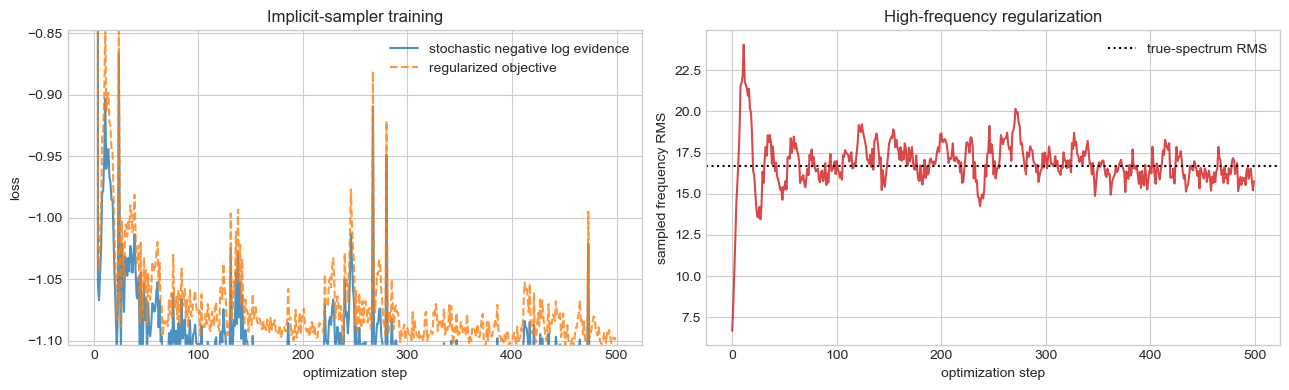

,quantity,value
0,noise dimension $K$,8.000000
1,output dimension $D$,1.000000
2,RFF samples $L$,256.000000
3,output variance,1.186628
4,noise variance,0.002506
5,frequency scale,74.055038
6,final sampled RMS,15.774465
7,true-spectrum RMS,16.707085
8,penalty weight,0.000100


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.negative_mll, alpha=0.8, label='stochastic negative log evidence')
axes[0].plot(history.objective, '--', alpha=0.8, label='regularized objective')
axes[0].set(xlabel='optimization step', ylabel='loss', title='Implicit-sampler training')
axes[0].set_ylim(np.percentile(history.objective, 1), np.percentile(history.objective, 99))
axes[0].legend()

true_rms = np.sqrt(np.sum(mixture_weights * (angular_frequencies**2 + lengthscales**-2)))
axes[1].plot(history.frequency_rms, color='C3', alpha=0.85)
axes[1].axhline(true_rms, color='black', ls=':', label='true-spectrum RMS')
axes[1].set(xlabel='optimization step', ylabel='sampled frequency RMS',
            title='High-frequency regularization')
axes[1].legend()
fig.tight_layout()
plt.show()

implicit_kernel = implicit_model.covar_module.base_kernel
pd.DataFrame({
    'quantity': ['noise dimension $K$', 'output dimension $D$', 'RFF samples $L$',
                 'output variance', 'noise variance', 'frequency scale',
                 'final sampled RMS', 'true-spectrum RMS', 'penalty weight'],
    'value': [K, D, L,
              float(implicit_model.covar_module.outputscale.detach()),
              float(implicit_likelihood.noise.detach()),
              float(implicit_kernel.frequency_scale.detach()),
              history.frequency_rms[-1], true_rms, frequency_penalty_weight],
})


## 6. Learned implicit spectrum

Although the sampler does not expose a density, we can estimate its one-dimensional distribution with many fresh samples and compare their histogram with the analytic true mixture.

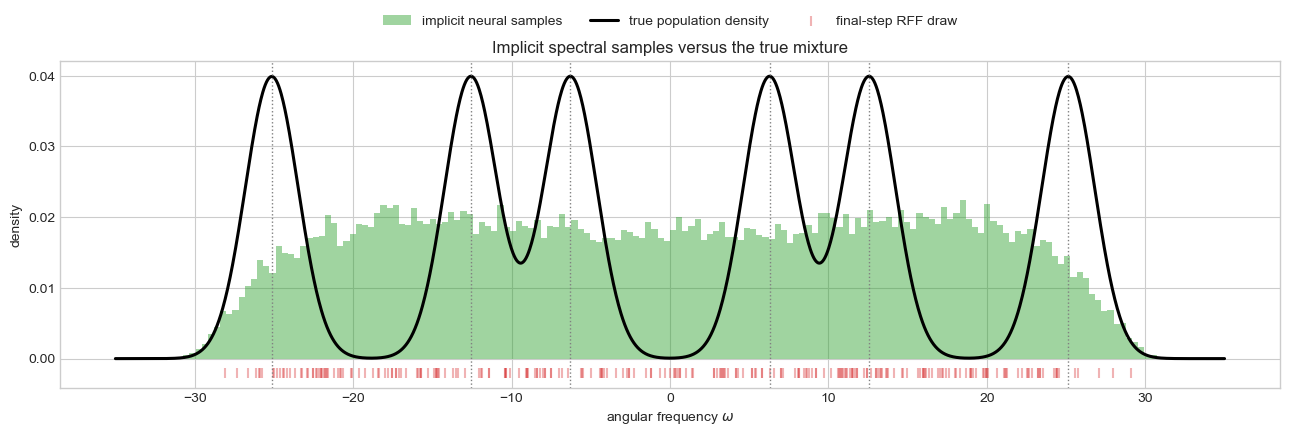

In [6]:
implicit_model.eval()
implicit_likelihood.eval()
with torch.no_grad():
    learned_samples = implicit_kernel.draw_frequencies(40_000, seed=2028).cpu().numpy()[:, 0]
    final_rff_frequencies = implicit_kernel.frequencies().cpu().numpy()[:, 0]

omega_grid = np.linspace(-35, 35, 1800)
true_density = np.zeros_like(omega_grid)
for weight, center, ell in zip(mixture_weights, angular_frequencies, lengthscales):
    spectral_std = 1 / ell
    normalizer = spectral_std * np.sqrt(2 * np.pi)
    true_density += 0.5 * weight * np.exp(-0.5*((omega_grid-center)/spectral_std)**2) / normalizer
    true_density += 0.5 * weight * np.exp(-0.5*((omega_grid+center)/spectral_std)**2) / normalizer

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.hist(learned_samples, bins=180, range=(-35, 35), density=True, alpha=0.45,
        color='C2', label='implicit neural samples')
ax.plot(omega_grid, true_density, color='black', lw=2.2, label='true population density')
ax.scatter(final_rff_frequencies, np.full_like(final_rff_frequencies, -0.002),
           marker='|', s=42, alpha=0.35, color='C3', label='final-step RFF draw')
for center in angular_frequencies:
    ax.axvline(center, color='gray', ls=':', lw=1)
    ax.axvline(-center, color='gray', ls=':', lw=1)
ax.set(xlabel=r'angular frequency $\omega$', ylabel='density',
       title='Implicit spectral samples versus the true mixture')
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.18))
fig.tight_layout()
plt.show()


## 7. The induced stationary kernel

Density recovery is not the final objective. The GP uses the covariance induced by the finite RFF draw, which we compare with

$$k_{\rm avg}(\tau)=\sum_m\pi_m\exp\!\left(-\frac{\tau^2}{2\ell_m^2}\right)\cos(\omega_m\tau).$$

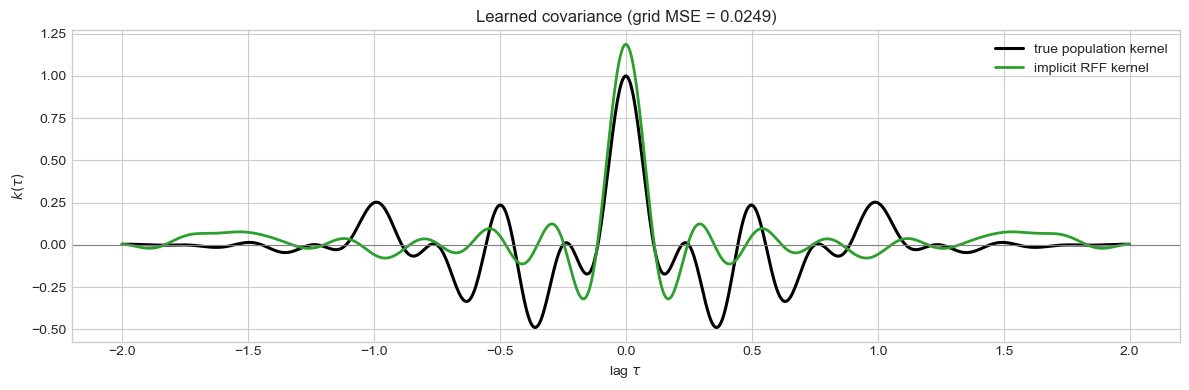

In [7]:
tau = np.linspace(-2, 2, 800)
true_kernel = sum(
    weight * np.exp(-tau**2/(2*ell**2)) * np.cos(center*tau)
    for weight, center, ell in zip(mixture_weights, angular_frequencies, lengthscales)
)
outputscale = float(implicit_model.covar_module.outputscale.detach())
learned_kernel = outputscale * np.cos(tau[:, None] * final_rff_frequencies[None, :]).mean(axis=1)
kernel_mse = np.mean((learned_kernel - true_kernel)**2)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau, true_kernel, color='black', lw=2.2, label='true population kernel')
ax.plot(tau, learned_kernel, color='C2', lw=2, label='implicit RFF kernel')
ax.axhline(0, color='gray', lw=0.8)
ax.set(xlabel=r'lag $\tau$', ylabel=r'$k(\tau)$',
       title=f'Learned covariance (grid MSE = {kernel_mse:.4f})')
ax.legend()
fig.tight_layout()
plt.show()


## 8. Sparse observations from held-out signals

The learned sampler and final RFF kernel are shared by the population. For each test signal, we condition that GP on independently sampled, non-uniform observation locations.

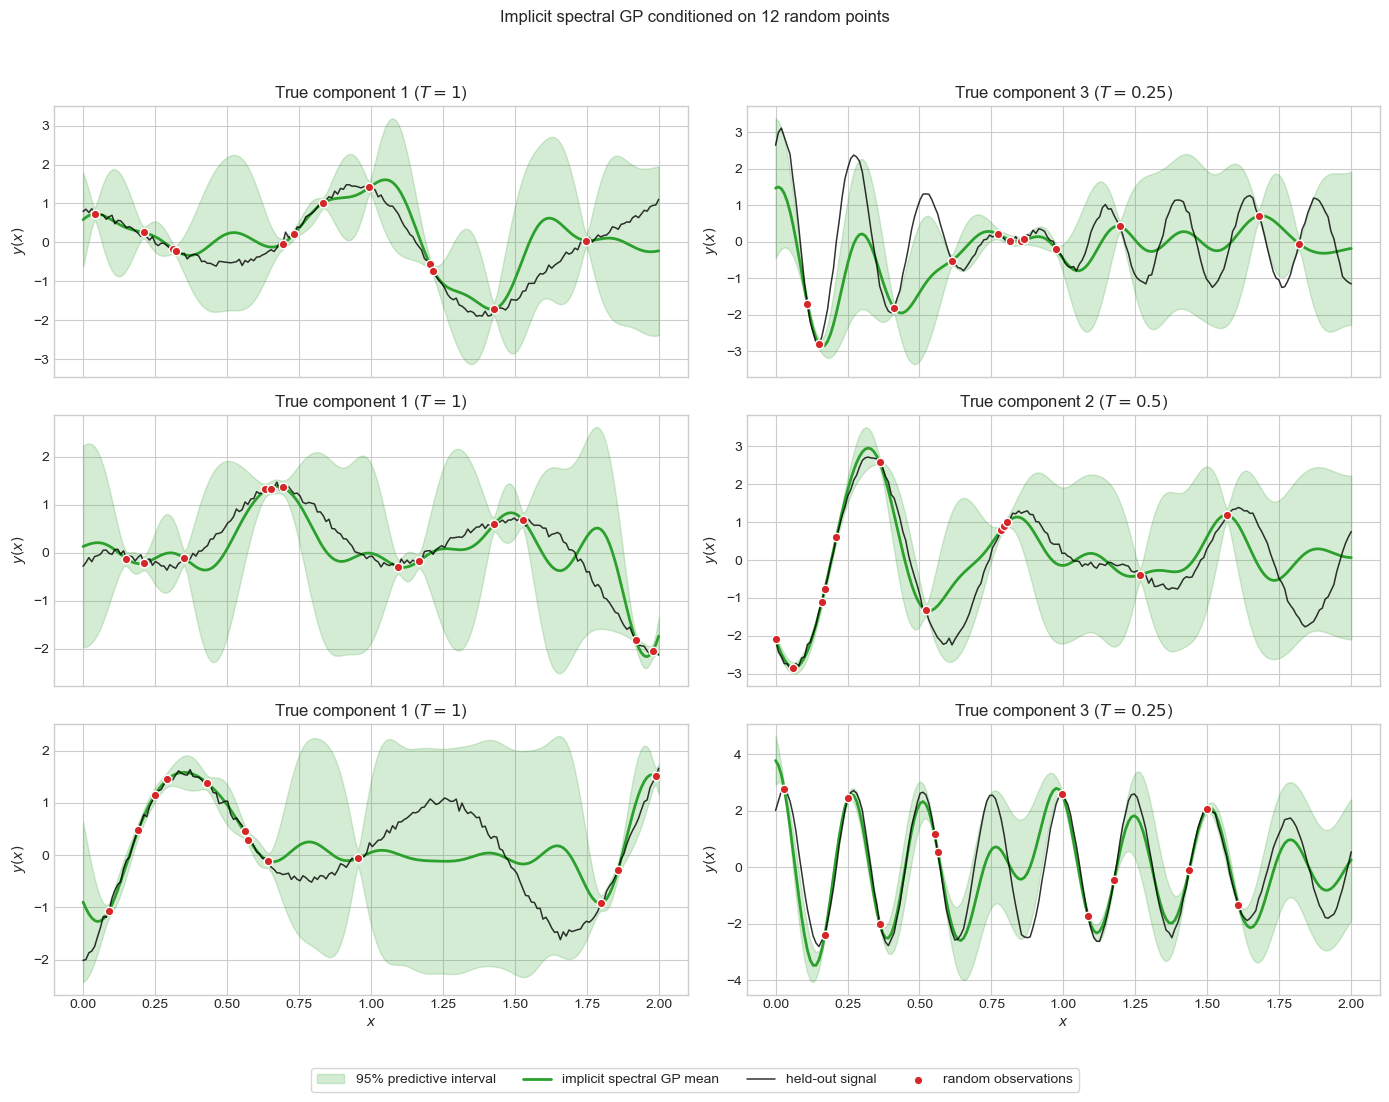

In [8]:
n_examples = 6
n_observed = 12
display_rng = np.random.default_rng(114)
chosen_test = display_rng.choice(len(test_curves), size=n_examples, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
axes = axes.ravel()
legend_handles = legend_labels = None
for ax, test_position in zip(axes, chosen_test):
    observed_indices = np.sort(display_rng.choice(len(x), size=n_observed, replace=False))
    prediction = predict_sparse_signal(
        implicit_model, implicit_likelihood,
        observed_x=x[observed_indices],
        observed_y=test_curves[test_position, observed_indices],
        prediction_x=x,
    )
    ax.fill_between(x, prediction.lower, prediction.upper, color='C2', alpha=0.2,
                    label='95% predictive interval')
    ax.plot(x, prediction.mean, color='C2', lw=2, label='implicit spectral GP mean')
    ax.plot(x, test_curves[test_position], color='black', lw=1.1, alpha=0.8,
            label='held-out signal')
    ax.scatter(x[observed_indices], test_curves[test_position, observed_indices],
               color='C3', edgecolor='white', s=38, zorder=4, label='random observations')
    component = test_labels[test_position]
    ax.set_title(f'True component {component+1} ($T={periods[component]:g}$)')
    ax.set_ylabel('$y(x)$')
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()
for ax in axes[-2:]:
    ax.set_xlabel('$x$')
fig.suptitle(f'Implicit spectral GP conditioned on {n_observed} random points', y=0.995)
fig.legend(legend_handles, legend_labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, 0.005), frameon=True)
fig.tight_layout(rect=(0, 0.055, 1, 0.97))
plt.show()


## 9. Conclusions

- A dense generator $g_\theta:\mathbb R^K\to\mathbb R^D$ can define a flexible spectral measure using samples alone; here $K=8$ and $D=1$.
- No inverse map, Jacobian determinant, or explicit spectral density is required because GP evidence depends on the resulting kernel samples.
- Fresh Gaussian noise and signs at every iteration train the model across Monte Carlo realizations rather than one fixed feature set.
- Random sign flips explicitly symmetrize the implicit measure, while paired sine/cosine RFFs yield a real stationary covariance.
- The frequency-norm penalty controls spurious rapid oscillations but must remain weak enough to preserve genuine high-frequency bands.
- As in the preceding notebook, one shared kernel learns population-average behavior rather than a separate spectral component for every curve.